### Part A – Tabular Medical Data
### Dataset: Pima Indians Diabetes Dataset

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, f_oneway

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

load the dataset

In [2]:
# Loading Pima Indians Diabetes Dataset

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

df = pd.read_csv(url, header=None)

print("Dataset loaded successfully!")

Dataset loaded successfully!


Give the columns proper names

In [3]:
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df.columns = columns

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


dataset size

In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (768, 9)

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# Statistical summary

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Check Missing Values

In [6]:
# Check missing values

df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [7]:
# Check zero values in medically meaningful columns

medical_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in medical_columns:
    print(column, ":", (df[column] == 0).sum(), "zero values")

Glucose : 5 zero values
BloodPressure : 35 zero values
SkinThickness : 227 zero values
Insulin : 374 zero values
BMI : 11 zero values


Data Cleaning

In [8]:
# Replace medically invalid zero values with NaN

df_clean = df.copy()

df_clean[medical_columns] = df_clean[medical_columns].replace(0, np.nan)

print("Missing values after replacement:")
print(df_clean.isnull().sum())

Missing values after replacement:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [9]:
# Fill missing values using median

for column in medical_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

print("Missing values after imputation:")
print(df_clean.isnull().sum())

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [10]:
# Check duplicate rows

print("Number of duplicate rows:", df_clean.duplicated().sum())

Number of duplicate rows: 0


In [11]:
#remove if present(duplicates)
df_clean = df_clean.drop_duplicates()

print("Shape after removing duplicates:", df_clean.shape)

Shape after removing duplicates: (768, 9)


Exploratory Data Analysis

Outcome
0    500
1    268
Name: count, dtype: int64


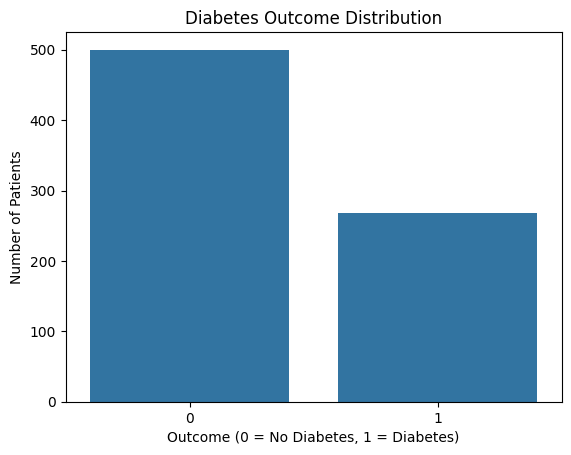

In [12]:
# Outcome distribution

print(df_clean["Outcome"].value_counts())

sns.countplot(x="Outcome", data=df_clean)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")

plt.show()

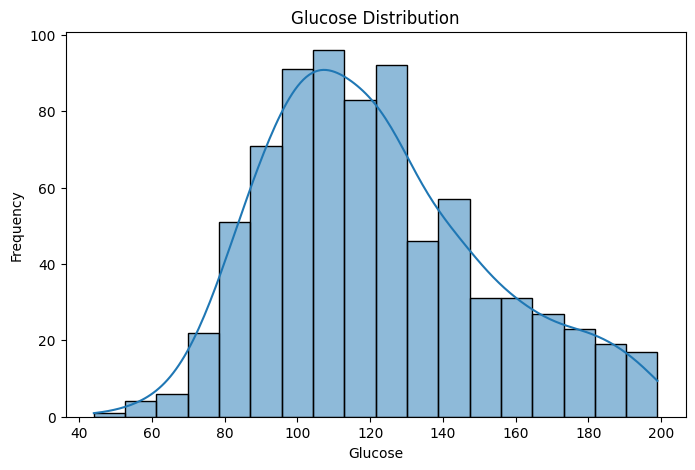

In [13]:
#Glucose Distribution
plt.figure(figsize=(8,5))

sns.histplot(data=df_clean, x="Glucose", kde=True)

plt.title("Glucose Distribution")
plt.xlabel("Glucose")
plt.ylabel("Frequency")

plt.show()

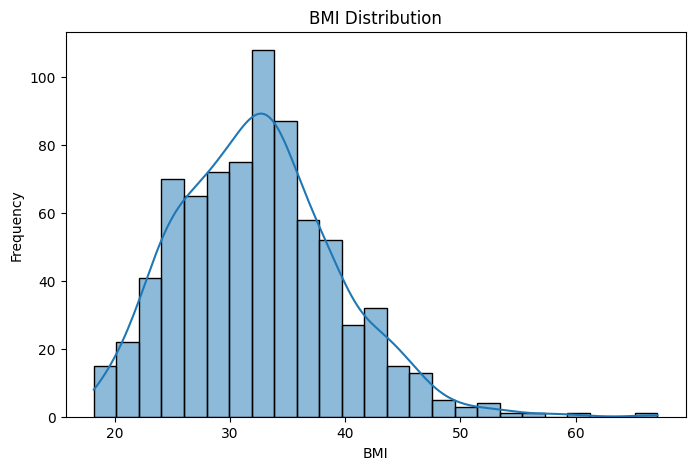

In [14]:
#BMI Distribution
plt.figure(figsize=(8,5))

sns.histplot(data=df_clean, x="BMI", kde=True)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

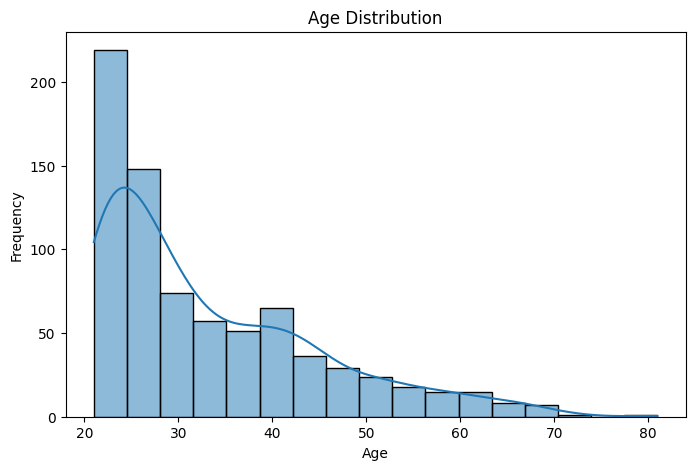

In [15]:
#Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(data=df_clean, x="Age", kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

Compare Features With Diabetes

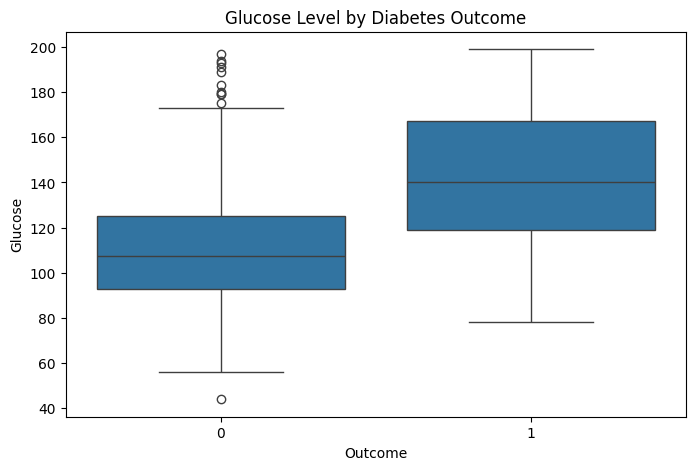

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df_clean, x="Outcome", y="Glucose")

plt.title("Glucose Level by Diabetes Outcome")

plt.show()

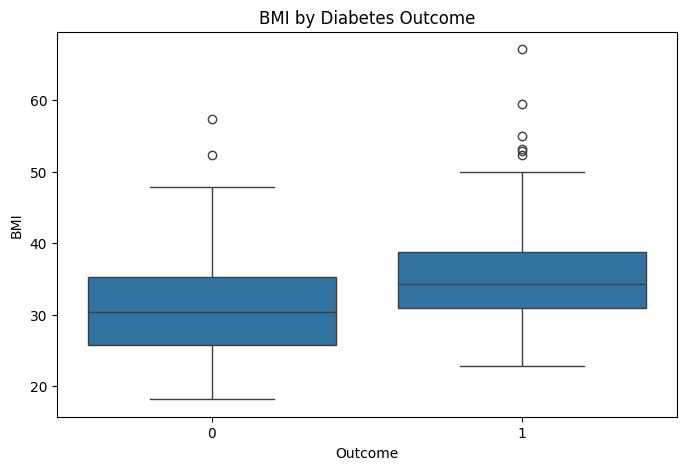

In [17]:
#BMI
plt.figure(figsize=(8,5))

sns.boxplot(data=df_clean, x="Outcome", y="BMI")

plt.title("BMI by Diabetes Outcome")

plt.show()

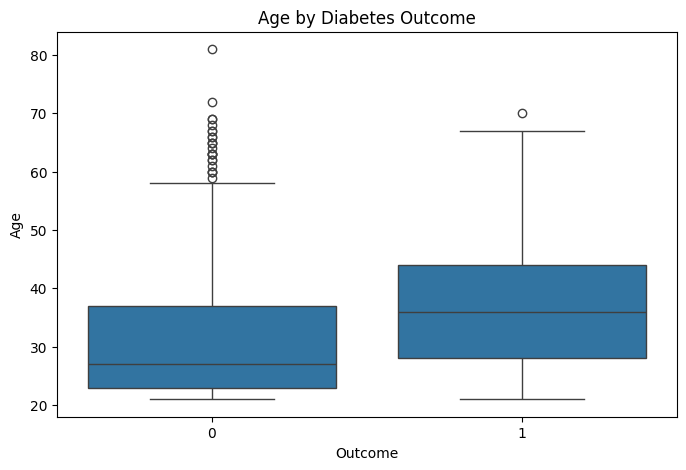

In [18]:
#Age
plt.figure(figsize=(8,5))

sns.boxplot(data=df_clean, x="Outcome", y="Age")

plt.title("Age by Diabetes Outcome")

plt.show()

Correlation Analysis

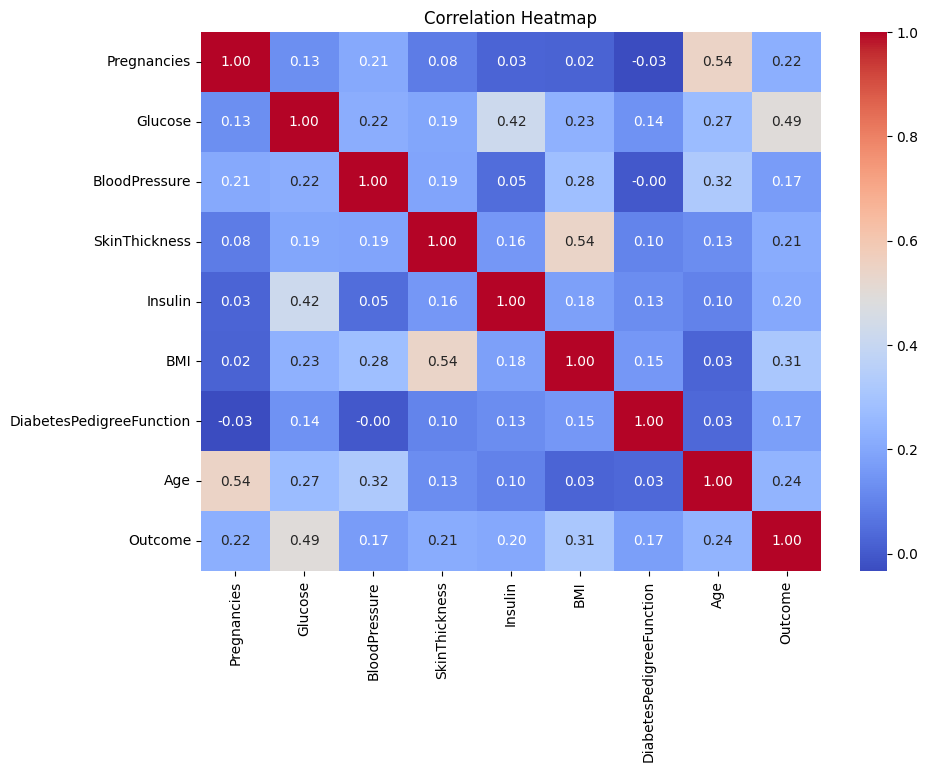

In [19]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df_clean.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Feature Engineering

In [20]:


df_clean["BMI_Age"] = df_clean["BMI"] * df_clean["Age"]

df_clean["Glucose_BMI"] = df_clean["Glucose"] / df_clean["BMI"]

df_clean.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Age,Glucose_BMI
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,1680.0,4.404762
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,824.6,3.195489
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,745.6,7.854077
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,590.1,3.167260
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,1422.3,3.178654


In [21]:
print(df_clean.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'BMI_Age',
       'Glucose_BMI'],
      dtype='object')


Feature Selection

In [22]:
X = df_clean.drop("Outcome", axis=1)

y = df_clean["Outcome"]

print("Features:", X.columns.tolist())
print("Target: Outcome")

Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'BMI_Age', 'Glucose_BMI']
Target: Outcome


In [23]:
selector = SelectKBest(score_func=f_classif, k=5)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features.tolist())

Selected Features:
['Pregnancies', 'Glucose', 'BMI', 'Age', 'BMI_Age']


Feature Scaling

In [24]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,BMI_Age,Glucose_BMI
0,0.639947,0.866045,-0.031990,0.670643,-0.181541,0.166619,0.468492,1.425995,1.369266,0.486666
1,-0.844885,-1.205066,-0.528319,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672,-0.585805,-0.610463
2,1.233880,2.016662,-0.693761,-0.012301,-0.181541,-1.332500,0.604397,-0.105584,-0.766365,3.616101
3,-0.844885,-1.073567,-0.528319,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549,-1.121770,-0.636074
4,-1.141852,0.504422,-2.679076,0.670643,0.316566,1.549303,5.484909,-0.020496,0.780276,-0.625736


Hypothesis Testing

In [25]:
diabetic = df_clean[df_clean["Outcome"] == 1]["Glucose"]

non_diabetic = df_clean[df_clean["Outcome"] == 0]["Glucose"]

t_stat, p_value = stats.ttest_ind(
    diabetic,
    non_diabetic,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 14.852653441079662
P-value: 3.5421485614431447e-41


In [26]:
#Decision:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: There is a statistically significant difference.")
else:
    print("Fail to reject H0: No statistically significant difference.")

Reject H0: There is a statistically significant difference.


Chi-Square Test

In [27]:
df_clean["Glucose_Category"] = pd.cut(
    df_clean["Glucose"],
    bins=[0, 100, 125, np.inf],
    labels=["Normal", "Prediabetes", "High"]
)

contingency_table = pd.crosstab(
    df_clean["Glucose_Category"],
    df_clean["Outcome"]
)

print(contingency_table)

Outcome             0    1
Glucose_Category          
Normal            191   18
Prediabetes       188   74
High              121  176


In [28]:
#Run Chi-square:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("P-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 146.2519911956344
P-value: 1.7449525756240475e-32
Degrees of freedom: 2


In [29]:
# Decision
if p < 0.05:
    print("Reject H0: Glucose category and diabetes outcome are significantly associated.")
else:
    print("Fail to reject H0: No significant association found.")

Reject H0: Glucose category and diabetes outcome are significantly associated.


ANOVA

In [30]:
# Create Age Groups
df_clean["Age_Group"] = pd.cut(
    df_clean["Age"],
    bins=[0, 30, 50, np.inf],
    labels=["Young", "Middle", "Older"]
)

In [31]:
young = df_clean[df_clean["Age_Group"] == "Young"]["Glucose"]

middle = df_clean[df_clean["Age_Group"] == "Middle"]["Glucose"]

older = df_clean[df_clean["Age_Group"] == "Older"]["Glucose"]
f_stat, p_value = f_oneway(
    young,
    middle,
    older
)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 29.597220170305267
P-value: 4.1605055255651603e-13


In [32]:
# Decision
if p_value < 0.05:
    print("Reject H0: At least one age group has a significantly different mean glucose level.")
else:
    print("Fail to reject H0: No statistically significant difference found.")

Reject H0: At least one age group has a significantly different mean glucose level.


Final Model-Ready Dataset

In [33]:
final_df = df_clean.drop(
    ["Glucose_Category", "Age_Group"],
    axis=1
)

print("Final dataset shape:", final_df.shape)

final_df.head()

Final dataset shape: (768, 11)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Age,Glucose_BMI
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,1680.0,4.404762
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,824.6,3.195489
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,745.6,7.854077
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,590.1,3.167260
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,1422.3,3.178654


In [34]:
print("Missing values:")
print(final_df.isnull().sum())

print("\nFinal columns:")
print(final_df.columns.tolist())

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
BMI_Age                     0
Glucose_BMI                 0
dtype: int64

Final columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'BMI_Age', 'Glucose_BMI']


# Part B – Image Medical Data

## Dataset: Chest X-Ray Images (Pneumonia)

In [35]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("Libraries imported successfully!")

Libraries imported successfully!



# load the dataset from the site

In [36]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [37]:
dataset_path = "/kaggle/input/chest-xray-pneumonia"

print(dataset_path)

/kaggle/input/chest-xray-pneumonia


In [38]:
import os

print(os.listdir(dataset_path))

['chest_xray']


In [39]:
dataset_path = "/kaggle/input/chest-xray-pneumonia/chest_xray"

print(os.listdir(dataset_path))

['chest_xray', '__MACOSX', 'val', 'test', 'train']


Set train, test and validation paths

In [40]:
train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")
val_dir = os.path.join(dataset_path, "val")

print("Train:", train_dir)
print("Test:", test_dir)
print("Validation:", val_dir)

Train: /kaggle/input/chest-xray-pneumonia/chest_xray/train
Test: /kaggle/input/chest-xray-pneumonia/chest_xray/test
Validation: /kaggle/input/chest-xray-pneumonia/chest_xray/val


Check classes

In [41]:
print("Train classes:", os.listdir(train_dir))
print("Test classes:", os.listdir(test_dir))
print("Validation classes:", os.listdir(val_dir))

Train classes: ['PNEUMONIA', 'NORMAL']
Test classes: ['PNEUMONIA', 'NORMAL']
Validation classes: ['PNEUMONIA', 'NORMAL']


Count images

In [42]:
def count_images(folder):
    normal = len(os.listdir(os.path.join(folder, "NORMAL")))
    pneumonia = len(os.listdir(os.path.join(folder, "PNEUMONIA")))

    return normal, pneumonia


train_normal, train_pneumonia = count_images(train_dir)
test_normal, test_pneumonia = count_images(test_dir)
val_normal, val_pneumonia = count_images(val_dir)

print("TRAIN")
print("Normal:", train_normal)
print("Pneumonia:", train_pneumonia)

print("\nTEST")
print("Normal:", test_normal)
print("Pneumonia:", test_pneumonia)

print("\nVALIDATION")
print("Normal:", val_normal)
print("Pneumonia:", val_pneumonia)

TRAIN
Normal: 1341
Pneumonia: 3875

TEST
Normal: 234
Pneumonia: 390

VALIDATION
Normal: 8
Pneumonia: 8


Make Distribution Table

In [43]:
distribution = pd.DataFrame({
    "Dataset": ["Train", "Test", "Validation"],
    "NORMAL": [train_normal, test_normal, val_normal],
    "PNEUMONIA": [train_pneumonia, test_pneumonia, val_pneumonia]
})

distribution

,Dataset,NORMAL,PNEUMONIA
0,Train,1341,3875
1,Test,234,390
2,Validation,8,8


Plot class distribution

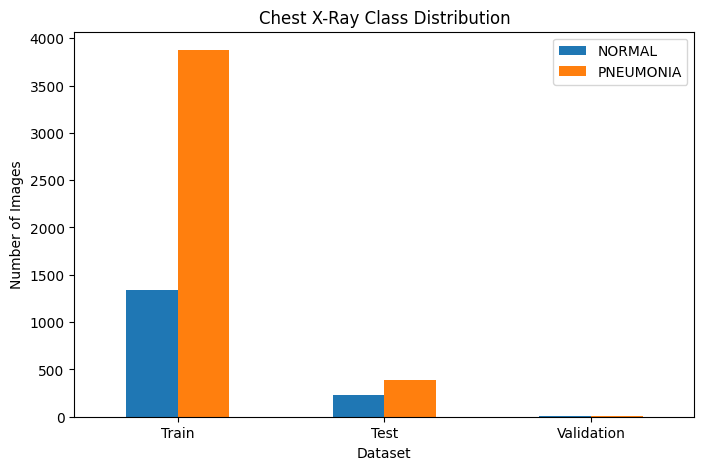

In [44]:
distribution.set_index("Dataset").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Chest X-Ray Class Distribution")
plt.xlabel("Dataset")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.show()

Display X-rays

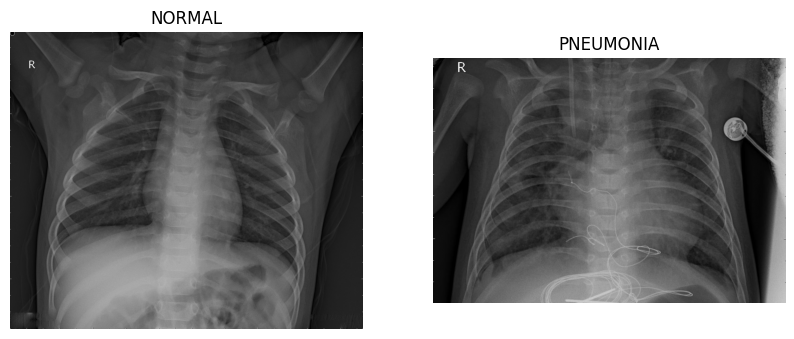

In [45]:
from PIL import Image

normal_images = os.listdir(os.path.join(train_dir, "NORMAL"))
pneumonia_images = os.listdir(os.path.join(train_dir, "PNEUMONIA"))

normal_path = os.path.join(
    train_dir, "NORMAL", normal_images[0]
)

pneumonia_path = os.path.join(
    train_dir, "PNEUMONIA", pneumonia_images[0]
)

normal_img = Image.open(normal_path)
pneumonia_img = Image.open(pneumonia_path)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(normal_img, cmap="gray")
plt.title("NORMAL")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pneumonia_img, cmap="gray")
plt.title("PNEUMONIA")
plt.axis("off")

plt.show()

Check image properties

In [46]:
print("NORMAL")
print("Size:", normal_img.size)
print("Mode:", normal_img.mode)

print("\nPNEUMONIA")
print("Size:", pneumonia_img.size)
print("Mode:", pneumonia_img.mode)

NORMAL
Size: (1336, 1128)
Mode: L

PNEUMONIA
Size: (1024, 712)
Mode: L


Check corrupted images

In [47]:
def check_images(folder):
    corrupted = []

    for class_name in ["NORMAL", "PNEUMONIA"]:
        class_path = os.path.join(folder, class_name)

        for file in os.listdir(class_path):
            file_path = os.path.join(class_path, file)

            try:
                img = Image.open(file_path)
                img.verify()
            except:
                corrupted.append(file_path)

    return corrupted


corrupted_images = check_images(train_dir)

print("Corrupted training images:", len(corrupted_images))

Corrupted training images: 0


Resize + preprocessing

In [48]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [49]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


Check labels

In [49]:
print(train_generator.class_indices)

Check image tensors

In [50]:
images, labels = next(train_generator)

print("Image tensor shape:", images.shape)
print("Labels shape:", labels.shape)

Image tensor shape: (32, 224, 224, 3)
Labels shape: (32,)


Data Augmentation

In [51]:
augmentation_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True
)

augmented_train_generator = augmentation_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

Found 5216 images belonging to 2 classes.


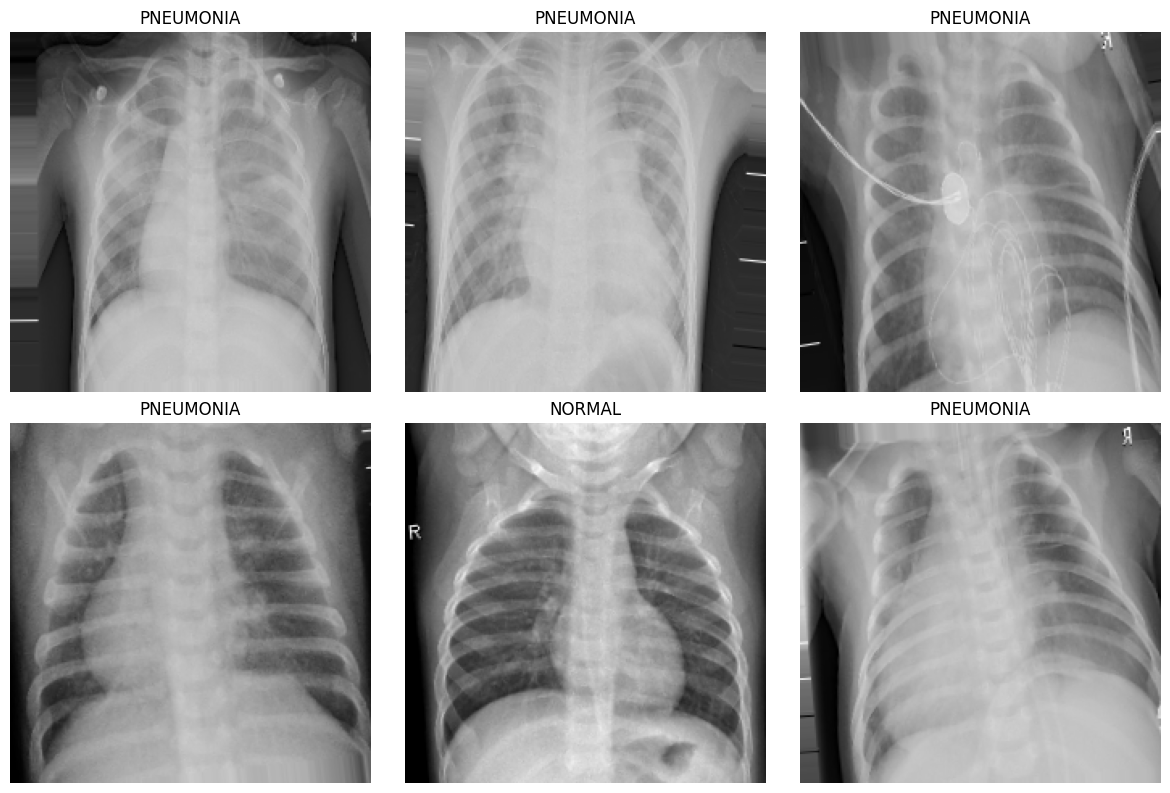

In [52]:
#Visualize:
aug_images, aug_labels = next(augmented_train_generator)

plt.figure(figsize=(12,8))

for i in range(6):
    plt.subplot(2,3,i+1)

    img = (aug_images[i] + 1) / 2
    img = np.clip(img, 0, 1)

    plt.imshow(img)

    label = "PNEUMONIA" if aug_labels[i] == 1 else "NORMAL"
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

Feature Extraction

In [53]:
from tensorflow.keras.applications import MobileNetV2

feature_extractor = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)

feature_extractor.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [54]:
# Extract features:
images, labels = next(train_generator)

features = feature_extractor.predict(images)

print("Image shape:", images.shape)
print("Feature shape:", features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Image shape: (32, 224, 224, 3)
Feature shape: (32, 1280)


Pixel analysis

In [55]:
gray_img = normal_img.convert("L")

pixel_values = np.array(gray_img)

print("Minimum:", pixel_values.min())
print("Maximum:", pixel_values.max())
print("Mean:", pixel_values.mean())
print("Standard deviation:", pixel_values.std())

Minimum: 0
Maximum: 255
Mean: 73.29778275895019
Standard deviation: 38.16525364706324


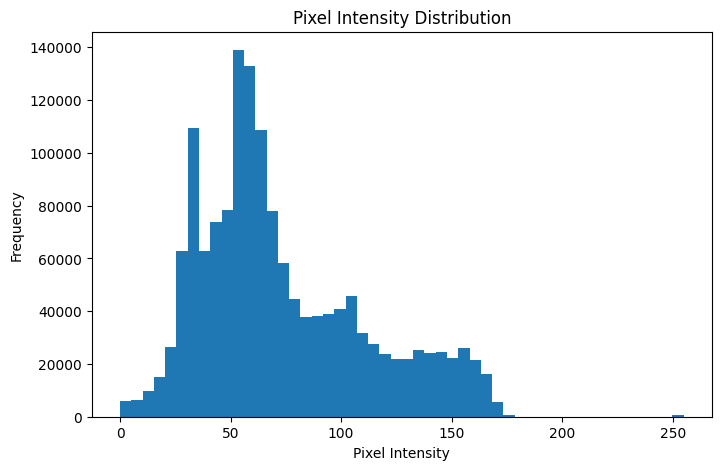

In [56]:
#plot:
plt.figure(figsize=(8,5))

plt.hist(pixel_values.flatten(), bins=50)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

Final summary

In [57]:
print("========== IMAGE DATA SUMMARY ==========")

print("Training NORMAL:", train_normal)
print("Training PNEUMONIA:", train_pneumonia)

print("Testing NORMAL:", test_normal)
print("Testing PNEUMONIA:", test_pneumonia)

print("Validation NORMAL:", val_normal)
print("Validation PNEUMONIA:", val_pneumonia)

print("\nImage size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Tensor shape:", images.shape)
print("Feature shape:", features.shape)

========== IMAGE DATA SUMMARY ==========
Training NORMAL: 1341
Training PNEUMONIA: 3875
Testing NORMAL: 234
Testing PNEUMONIA: 390
Validation NORMAL: 8
Validation PNEUMONIA: 8

Image size: (224, 224)
Batch size: 32
Tensor shape: (32, 224, 224, 3)
Feature shape: (32, 1280)


### Healthcare Privacy Consideration

The dataset contains JPEG chest X-ray images rather than DICOM medical
files. Therefore, DICOM patient-header anonymization is not directly
applicable to this dataset.

In a real clinical environment, DICOM metadata containing patient
identifying information must be removed or anonymized before processing.

# Part C – Textual Medical Data

## Dataset: MTSamples Medical Transcriptions

In [58]:
# Import libraries
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

print("Libraries imported successfully!")

Libraries imported successfully!


Download dataset using KaggleHub

In [59]:
import kagglehub

path = kagglehub.dataset_download("tboyle10/medicaltranscriptions")

print("Path to dataset files:", path)

100%|██████████| 4.85M/4.85M [00:00<00:00, 39.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tboyle10/medicaltranscriptions/versions/1


CSV file

In [60]:
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/root/.cache/kagglehub/datasets/tboyle10/medicaltranscriptions/versions/1/mtsamples.csv


Load the CSV

In [61]:
csv_path = None

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_path = os.path.join(root, file)
            break

print("CSV file:", csv_path)

CSV file: /root/.cache/kagglehub/datasets/tboyle10/medicaltranscriptions/versions/1/mtsamples.csv


In [62]:
df_text = pd.read_csv(csv_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


Inspect dataset

In [63]:
print("Shape:", df_text.shape)

print("\nColumns:")
print(df_text.columns.tolist())

print("\nFirst 5 records:")
df_text.head()

Shape: (4999, 6)

Columns:
['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

First 5 records:


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


Dataset information

In [64]:
df_text.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4999 non-null   int64 
 1   description        4999 non-null   object
 2   medical_specialty  4999 non-null   object
 3   sample_name        4999 non-null   object
 4   transcription      4966 non-null   object
 5   keywords           3931 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB


In [65]:
df_text.describe(include="all")

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
count,4999.000000,4999,4999,4999,4966,3931
unique,NaN,2348,40,2377,2357,3849
top,NaN,An example/template for a routine normal male...,Surgery,Lumbar Discogram,"PREOPERATIVE DIAGNOSIS: , Low back pain.,POSTO...",
freq,NaN,12,1103,5,5,81
mean,2499.000000,NaN,NaN,NaN,NaN,NaN
std,1443.231328,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN
25%,1249.500000,NaN,NaN,NaN,NaN,NaN
50%,2499.000000,NaN,NaN,NaN,NaN,NaN
75%,3748.500000,NaN,NaN,NaN,NaN,NaN


Missing-value analysis

In [66]:
print("Missing values:")
print(df_text.isnull().sum())

Missing values:
Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64


In [67]:
print("Missing transcriptions:",
      df_text["transcription"].isnull().sum())

print("Missing specialties:",
      df_text["medical_specialty"].isnull().sum())

Missing transcriptions: 33
Missing specialties: 0


Remove records without transcription

In [68]:
df_text = df_text.dropna(
    subset=["transcription", "medical_specialty"]
).copy()

print("Shape after removing missing text:",
      df_text.shape)

Shape after removing missing text: (4966, 6)


Check duplicates

In [69]:
print("Duplicate rows:",
      df_text.duplicated().sum())

Duplicate rows: 0


In [70]:
#Remove Duplicates
df_text = df_text.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:",
      df_text.shape)

Shape after removing duplicates: (4966, 6)


Inspect medical specialties

In [71]:
print("Number of specialties:",
      df_text["medical_specialty"].nunique())

print("\nSpecialties:")
print(df_text["medical_specialty"].value_counts())

Number of specialties: 40

Specialties:
medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Obstetrics / Gynecology           155
Discharge Summary                 108
ENT - Otolaryngology               96
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    61
Psychiatry / Psychology            53
Office Notes                       50
Podiatry                           47
Dermatology                        29
Dentistry                     

Visualize medical specialties

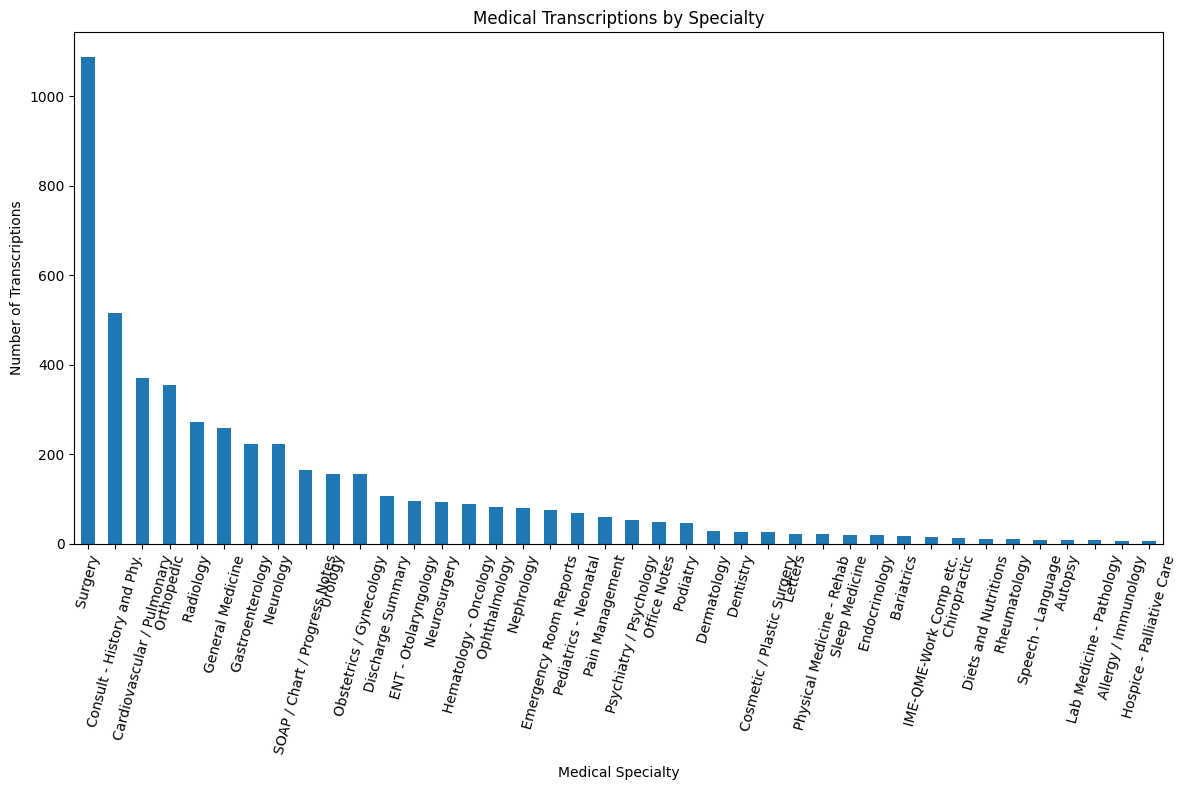

In [72]:
plt.figure(figsize=(12,8))

df_text["medical_specialty"].value_counts().plot(
    kind="bar"
)

plt.title("Medical Transcriptions by Specialty")
plt.xlabel("Medical Specialty")
plt.ylabel("Number of Transcriptions")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

Analyze transcription length

In [73]:
df_text["text_length"] = df_text["transcription"].str.len()

df_text["word_count"] = (
    df_text["transcription"]
    .str.split()
    .str.len()
)

df_text.head()

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords,text_length,word_count
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller...",1331,204
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh...",2431,350
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart...",4422,716
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple...",495,68
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo...",1618,229


In [74]:
df_text[["text_length", "word_count"]].describe()

,text_length,word_count
count,4966.000000,4966.000000
mean,3052.314337,465.448852
std,1994.082239,316.386344
min,11.000000,1.000000
25%,1608.000000,241.000000
50%,2667.000000,398.000000
75%,4011.000000,615.000000
max,18425.000000,3029.000000


Plot text length

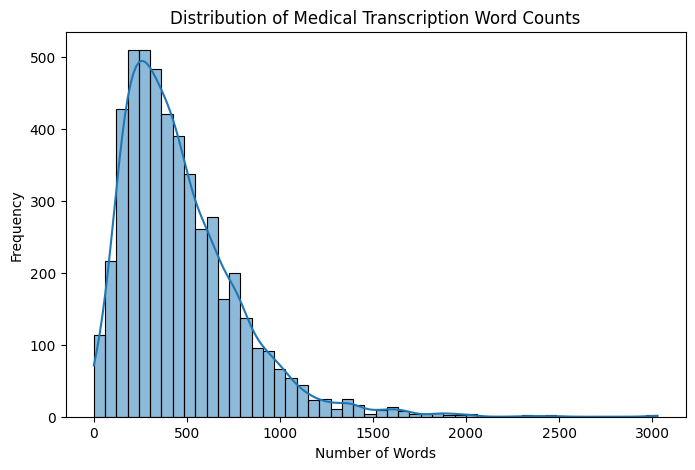

In [75]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_text["word_count"],
    bins=50,
    kde=True
)

plt.title("Distribution of Medical Transcription Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

Check very short texts

In [76]:
df_text.sort_values(
    "word_count"
)[[
    "medical_specialty",
    "transcription",
    "word_count"
]].head(10)

,medical_specialty,transcription,word_count
1362,SOAP / Chart / Progress Notes,"SUBJECTIVE:,",1
4625,Cardiovascular / Pulmonary,"INDICATIONS:,",1
1977,Pain Management,"OPERATION:,",1
3282,General Medicine,"SUBJECTIVE:,",1
1932,Pain Management,"OPERATION:,",1
1508,Radiology,"INDICATIONS:,",1
24,Urology,"CHIEF COMPLAINT:,",2
4063,Consult - History and Phy.,"CHIEF COMPLAINT:,",2
3555,Gastroenterology,"INDICATION: ,",2
862,Surgery,"INDICATION: ,",2


In [78]:
#remove short records
df_text = df_text[df_text["word_count"] >= 5].copy()
print("Shape after removing very short texts:", df_text.shape)

Shape after removing very short texts: (4946, 8)


Text Cleaning

In [79]:
def clean_text(text):

    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)

    # Remove special characters
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [80]:
df_text["cleaned_text"] = df_text["transcription"].apply(clean_text)

df_text[
    ["transcription", "cleaned_text"]
].head()

,transcription,cleaned_text
0,"SUBJECTIVE:, This 23-year-old white female pr...",subjective this 23 year old white female prese...
1,"PAST MEDICAL HISTORY:, He has difficulty climb...",past medical history he has difficulty climbin...
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...",history of present illness i have seen abc tod...
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...",2 d m mode 1 left atrial enlargement with left...
4,1. The left ventricular cavity size and wall ...,1 the left ventricular cavity size and wall th...


Healthcare privacy / PHI consideration

In [81]:
def remove_possible_identifiers(text):

    text = str(text)

    # Email addresses
    text = re.sub(
        r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
        " [EMAIL] ",
        text
    )

    # Phone numbers
    text = re.sub(
        r"\b\d{3}[-.\s]?\d{3}[-.\s]?\d{4}\b",
        " [PHONE] ",
        text
    )

    # URLs
    text = re.sub(
        r"https?://\S+|www\.\S+",
        " [URL] ",
        text
    )

    return text

In [82]:
df_text["deidentified_text"] = (
    df_text["transcription"]
    .apply(remove_possible_identifiers)
)

Stopword removal

In [118]:
df_text["cleaned_text"] = (
    df_text["deidentified_text"]
    .apply(clean_text)
)

df_text["processed_text"] = df_text["cleaned_text"]

df_text[["deidentified_text", "processed_text"]].head()

,deidentified_text,processed_text
0,"SUBJECTIVE:, This 23-year-old white female pr...",subjective this 23 year old white female prese...
1,"PAST MEDICAL HISTORY:, He has difficulty climb...",past medical history he has difficulty climbin...
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...",history of present illness i have seen abc tod...
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...",2 d m mode 1 left atrial enlargement with left...
4,1. The left ventricular cavity size and wall ...,1 the left ventricular cavity size and wall th...


Most common words

In [119]:
all_words = " ".join(
    df_text["processed_text"]
).split()

word_counts = Counter(all_words)

common_words = word_counts.most_common(20)

common_words

[('the', 149888),
 ('and', 82779),
 ('was', 71765),
 ('of', 59205),
 ('to', 50632),
 ('a', 43031),
 ('with', 35815),
 ('in', 32808),
 ('is', 26378),
 ('patient', 24208),
 ('no', 17874),
 ('she', 17593),
 ('for', 17047),
 ('he', 15544),
 ('were', 15535),
 ('on', 14694),
 ('this', 13949),
 ('at', 13492),
 ('then', 12430),
 ('right', 11587)]

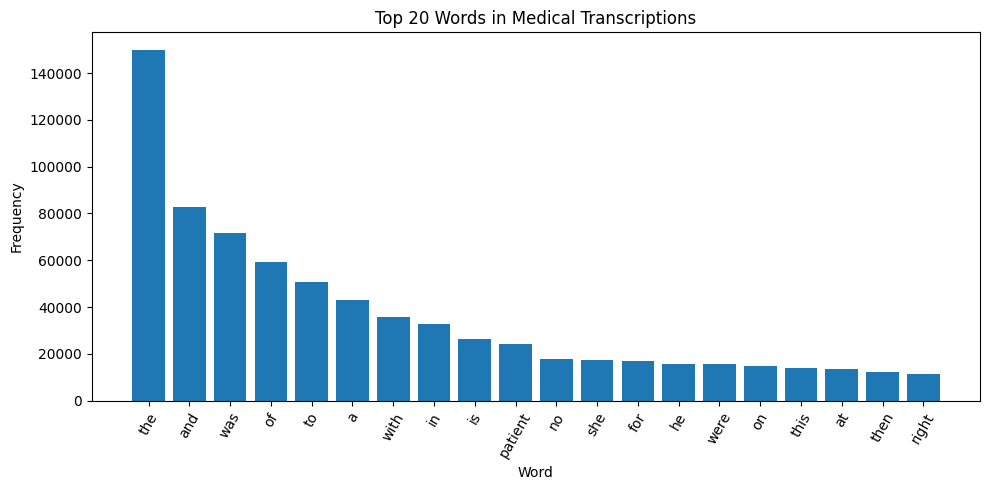

In [120]:
words = [x[0] for x in common_words]
counts = [x[1] for x in common_words]

plt.figure(figsize=(10,5))

plt.bar(words, counts)

plt.title("Top 20 Words in Medical Transcriptions")
plt.xlabel("Word")
plt.ylabel("Frequency")

plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

###  TF-IDF Feature Extraction

In [121]:
tfidf = TfidfVectorizer(
    max_features=2000,
    min_df=2,
    max_df=0.95
)

X_text = tfidf.fit_transform(
    df_text["processed_text"]
)

print("TF-IDF matrix shape:", X_text.shape)

TF-IDF matrix shape: (4946, 2000)


Get TF-IDF feature names

In [122]:
feature_names = tfidf.get_feature_names_out()

print("Number of extracted features:",
      len(feature_names))

print("\nFirst 20 features:")
print(feature_names[:20])

Number of extracted features: 2000

First 20 features:
['000' '01' '02' '03' '04' '05' '06' '07' '08' '09' '10' '100' '11' '12'
 '120' '125' '13' '14' '15' '150']


Convert target specialty into numbers

In [123]:
label_encoder = LabelEncoder()

y_text = label_encoder.fit_transform(
    df_text["medical_specialty"]
)

print("Encoded labels:")
print(y_text[:20])

Encoded labels:
[ 0  2  2  3  3  2  2  3  2  3  2  3 22  2  7  2  3  2 39 15]


In [124]:
label_mapping = dict(
    zip(
        label_encoder.classes_,
        range(len(label_encoder.classes_))
    )
)

label_mapping

{' Allergy / Immunology': 0,
 ' Autopsy': 1,
 ' Bariatrics': 2,
 ' Cardiovascular / Pulmonary': 3,
 ' Chiropractic': 4,
 ' Consult - History and Phy.': 5,
 ' Cosmetic / Plastic Surgery': 6,
 ' Dentistry': 7,
 ' Dermatology': 8,
 ' Diets and Nutritions': 9,
 ' Discharge Summary': 10,
 ' ENT - Otolaryngology': 11,
 ' Emergency Room Reports': 12,
 ' Endocrinology': 13,
 ' Gastroenterology': 14,
 ' General Medicine': 15,
 ' Hematology - Oncology': 16,
 ' Hospice - Palliative Care': 17,
 ' IME-QME-Work Comp etc.': 18,
 ' Lab Medicine - Pathology': 19,
 ' Letters': 20,
 ' Nephrology': 21,
 ' Neurology': 22,
 ' Neurosurgery': 23,
 ' Obstetrics / Gynecology': 24,
 ' Office Notes': 25,
 ' Ophthalmology': 26,
 ' Orthopedic': 27,
 ' Pain Management': 28,
 ' Pediatrics - Neonatal': 29,
 ' Physical Medicine - Rehab': 30,
 ' Podiatry': 31,
 ' Psychiatry / Psychology': 32,
 ' Radiology': 33,
 ' Rheumatology': 34,
 ' SOAP / Chart / Progress Notes': 35,
 ' Sleep Medicine': 36,
 ' Speech - Language': 37

Final text dataset

In [125]:
print("Final text feature matrix:")
print("X shape:", X_text.shape)

print("Target shape:", y_text.shape)

print("Number of classes:",
      len(label_encoder.classes_))

Final text feature matrix:
X shape: (4946, 2000)
Target shape: (4946,)
Number of classes: 40


Save processed dataset

In [126]:
df_text.to_csv(
    "/content/processed_mtsamples.csv",
    index=False
)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


Final summary

In [113]:
print("=" * 50)
print("FINAL TEXT DATA SUMMARY")
print("=" * 50)

print("Number of records:", len(df_text))

print("Number of specialties:",
      df_text["medical_specialty"].nunique())

print("TF-IDF feature count:",
      X_text.shape[1])

print("Number of target classes:",
      len(label_encoder.classes_))

print("\nMissing transcriptions:",
      df_text["transcription"].isnull().sum())

print("Duplicate rows:",
      df_text.duplicated().sum())

FINAL TEXT DATA SUMMARY
Number of records: 4946
Number of specialties: 40
TF-IDF feature count: 2000
Number of target classes: 40

Missing transcriptions: 0
Duplicate rows: 0


##Part D – Signal Medical Data
##Dataset: MIT-BIH Arrhythmia Database (ECG)

Import libraries + load ECG

In [95]:
!pip install wfdb -q

import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# Load ECG record 100 from MIT-BIH
record = wfdb.rdrecord('100', pn_dir='mitdb')

signal = record.p_signal[:, 0]
fs = record.fs

print("Sampling frequency:", fs, "Hz")
print("Number of samples:", len(signal))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.5 MB/s eta 0:00:00
Sampling frequency: 360 Hz
Number of samples: 650000


Visualize the raw ECG

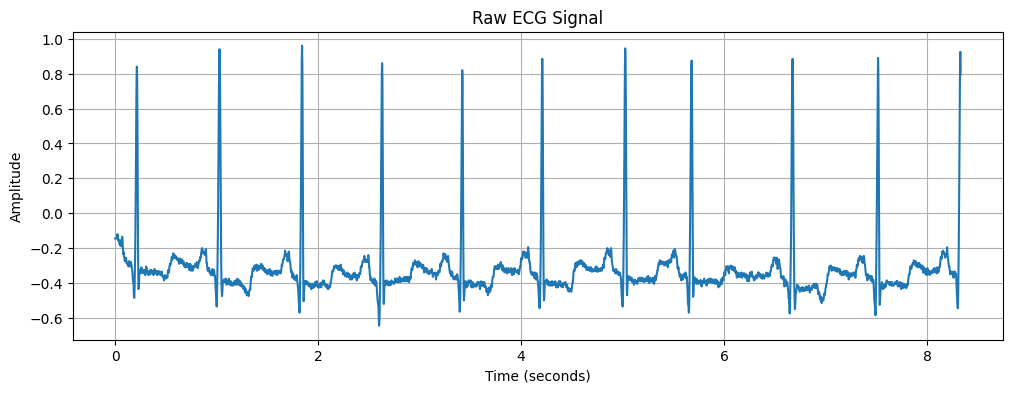

In [96]:
plt.figure(figsize=(12,4))

time = np.arange(len(signal)) / fs

plt.plot(time[:3000], signal[:3000])

plt.title("Raw ECG Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid()

plt.show()

# Remove noise using Bandpass Filter

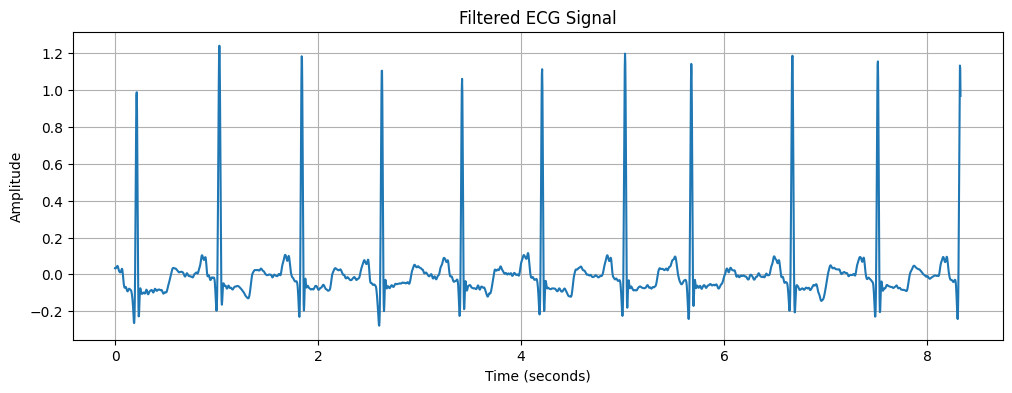

In [97]:
lowcut = 0.5
highcut = 40

b, a = butter(
    4,
    [lowcut/(fs/2), highcut/(fs/2)],
    btype="band"
)

filtered_signal = filtfilt(b, a, signal)

plt.figure(figsize=(12,4))

plt.plot(time[:3000], filtered_signal[:3000])

plt.title("Filtered ECG Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid()

plt.show()

Detect heartbeats + create signal windows

In [98]:
peaks, _ = find_peaks(
    filtered_signal,
    distance=int(0.6 * fs),
    prominence=0.3
)

print("Detected R-peaks:", len(peaks))

# Create windows around detected heartbeats
window_before = int(0.25 * fs)
window_after = int(0.45 * fs)

segments = []

for peak in peaks:
    start = peak - window_before
    end = peak + window_after

    if start >= 0 and end < len(filtered_signal):
        segments.append(filtered_signal[start:end])

segments = np.array(segments)

print("ECG segments shape:", segments.shape)

Detected R-peaks: 2263
ECG segments shape: (2261, 252)


 Feature extraction

In [99]:
import pandas as pd
features = pd.DataFrame({
    "Mean": np.mean(segments, axis=1),
    "Std": np.std(segments, axis=1),
    "Minimum": np.min(segments, axis=1),
    "Maximum": np.max(segments, axis=1),
    "RMS": np.sqrt(np.mean(segments**2, axis=1))
})

features.head()

,Mean,Std,Minimum,Maximum,RMS
0,0.007423,0.197906,-0.197444,1.240993,0.198045
1,0.004573,0.178405,-0.230532,1.183630,0.178464
2,0.003350,0.169554,-0.278717,1.105174,0.169587
3,-0.003654,0.160163,-0.225754,1.061056,0.160205
4,-0.000892,0.172036,-0.217574,1.113509,0.172038


ECG signal augmentation

In [100]:
# Add small random noise to create an augmented ECG signal

noise = np.random.normal(
    0,
    0.01,
    size=segments.shape
)

augmented_segments = segments + noise

print("Original shape:", segments.shape)
print("Augmented shape:", augmented_segments.shape)

Original shape: (2261, 252)
Augmented shape: (2261, 252)


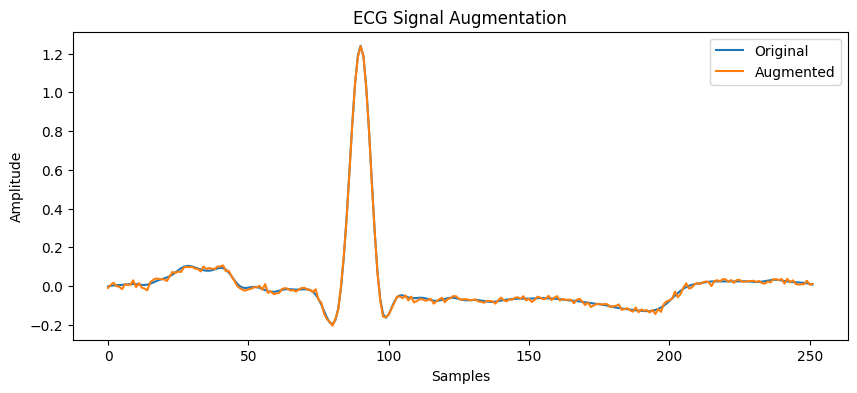

In [101]:
#Visualize:
plt.figure(figsize=(10,4))

plt.plot(segments[0], label="Original")
plt.plot(augmented_segments[0], label="Augmented")

plt.title("ECG Signal Augmentation")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()

plt.show()

Final model-ready data

In [102]:
X_ecg = segments[..., np.newaxis]

print("Final ECG tensor shape:", X_ecg.shape)
print("Feature table shape:", features.shape)

Final ECG tensor shape: (2261, 252, 1)
Feature table shape: (2261, 5)


original vs filtered ECG together

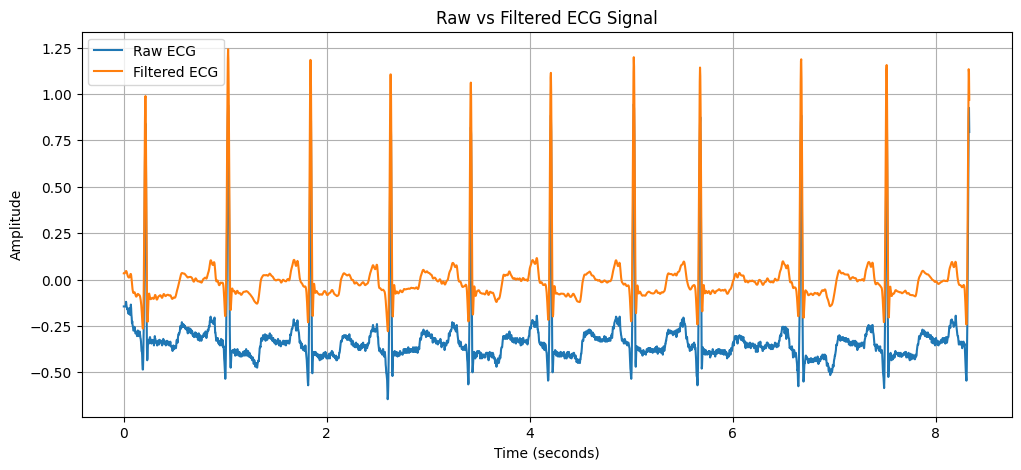

In [114]:
plt.figure(figsize=(12,5))

plt.plot(time[:3000], signal[:3000], label="Raw ECG")
plt.plot(time[:3000], filtered_signal[:3000], label="Filtered ECG")

plt.title("Raw vs Filtered ECG Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

plt.show()

Heartbeat

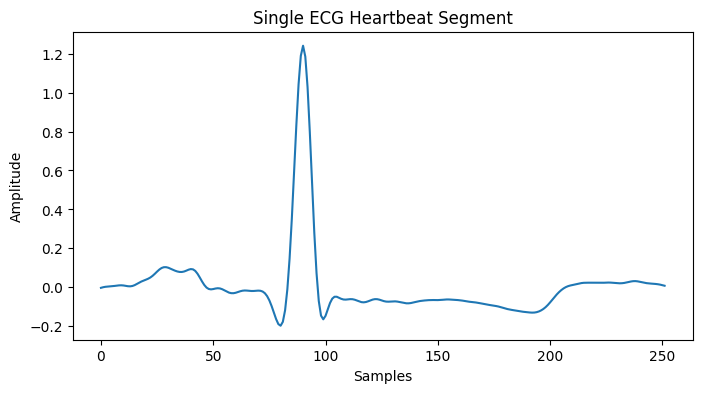

In [115]:
plt.figure(figsize=(8,4))

plt.plot(segments[0])

plt.title("Single ECG Heartbeat Segment")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()